<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="images/upct.png" alt="UPCT" style="height:45px; width:auto;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="images/umu.png" alt="UMU" style="height:45px; width:auto;">
</div>

___
### **Sesión 08**
## Segmentación basada en Bordes, Regiones, Clustering y Movimiento
___

### Objetivos
- Utilizar algoritmos de **detección de bordes** para segmentar imágenes digitales de manera efectiva.
- Aplicar técnicas de **segmentación basada en regiones**, incluyendo el crecimiento de regiones y el algoritmo de watershed.
- Explorar métodos de **segmentación por clustering**, como el algoritmo SLIC para la creación de superpíxeles.
- Implementar técnicas de **segmentación basada en movimiento** para detectar y rastrear objetos en secuencias de imágenes o videos.
- Desarrollar la capacidad de **ajustar y optimizar** estos métodos para mejorar la segmentación de imágenes.


### Contenidos
- [Revisión de Conceptos](#conceptos09)
- [Segmentación basada en Bordes](#bordes09)
- [Segmentación basada en Regiones](#regiones09)
- [Segmentación basada en Clustering](#clustering09)
- [Segmentación basada en Movimiento](#movimiento09)
- [Ejercicios de práctica](#ejercicios09)

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='conceptos09'></a>

## Revisión de Conceptos

### *Segmentación de Imágenes*

<div style="display:flex; justify-content:space-around; align-items:center;">
    <img src="images/segment.png" style="width:70%; height:auto;">
</div>
<br>

### *Tipos de Enfoques*

| Enfoque           | Descripción                                                                                                     | Métodos/Aplicaciones                                  |
|---------------------------|-----------------------------------------------------------------------------------------------------------------|-------------------------------------------------------|
| **Umbralización**         | Separa los píxeles de una imagen basándose en la intensidad del color, asignando píxeles a segmentos según umbrales específicos. | Métodos simples basados en un umbral global, umbralización adaptativa, y Otsu para determinar automáticamente el mejor umbral. |
| **Bordes**      | Identifica contornos de objetos mediante diferencias de intensidad.                                             | Algoritmos como Canny, Sobel, y Prewitt. Uso de técnicas de relleno para formar áreas segmentadas.           |
| **Regiones**    | Subdivide la imagen en áreas conectadas que representan objetos significativos.                                  | Técnicas como el Crecimiento de Regiones y Watershed.       |
| **Clustering**  | Agrupa píxeles basándose en características como color o textura para formar clústeres o superpíxeles.           | SLIC para la creación de superpíxeles basados en color y textura.|
| **Movimiento**  | Separa objetos en movimiento de aquellos estáticos en secuencias de video o imágenes.                            | Técnicas como sustracción de fondo, utilizando la mediana de los frames para establecer un fondo estático.  |

<br><br>

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='bordes09'></a>

## Segmentación basada en Bordes

La segmentación basada en bordes se centra en identificar los contornos de los objetos en una imagen y rellenar el interior de los bordes cerrados para segmentar claramente las diferentes regiones de la imagen. El siguiente código muestra cómo realizar esta operación en *scikit-image*.

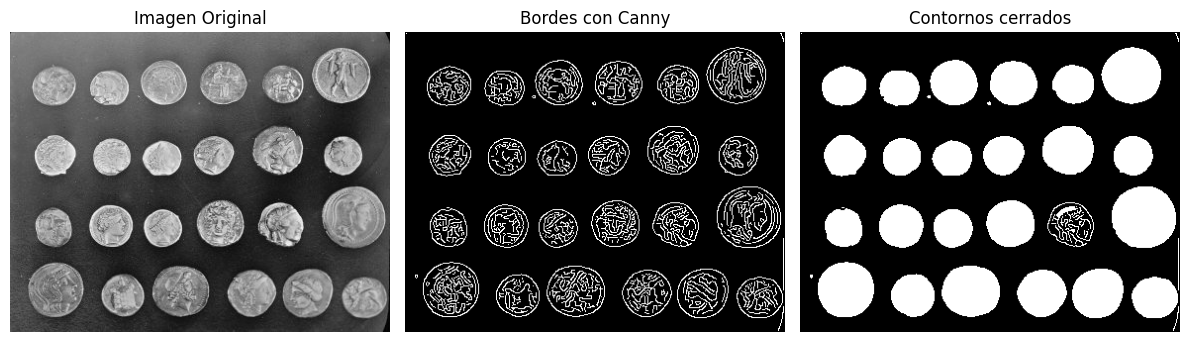

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import canny
from scipy import ndimage as ndi

# Cargar la imagen de monedas de skimage
coins = data.coins()

# Dividimos por 255 para normalizar los valores de intensidad entre 0 y 1 (opcional)
coins = coins / 255.0

# Detectamos los bordes en la imagen utilizando el algoritmo de Canny
edges = canny(coins)

# Rellenamos los contornos cerrados para obtener las regiones segmentadas
fill_coins = ndi.binary_fill_holes(edges)

# Mostrar los resultados
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].imshow(coins, cmap="gray"); axes[0].set_axis_off(); axes[0].set_title('Imagen Original')
axes[1].imshow(edges, cmap="gray"); axes[1].set_axis_off(); axes[1].set_title('Bordes con Canny')
axes[2].imshow(fill_coins, cmap="gray"); axes[2].set_axis_off(); axes[2].set_title('Contornos cerrados')
plt.tight_layout()
plt.show()

Como puedes observar, la función `binary_fill_holes` nos permite rellenar todos los contornos cerrados de la imagen, generando el correspondiente mapa de segmentación. Sin embargo, es importante destacar que el resultado obtenido no ha sido perfecto debido a que la configuración utilizada para Canny no ha segmentado correctamente todas las monedas, generando zonas de ruido y dejando incluso el contorno de una moneda sin cerrar. Para eliminar artefactos ruidosos, en futuras prácticas aplicaremos técnicas de morfología matemática. No obstante, por ahora nos centraremos en ajustar los parámetros del algoritmo de Canny para lograr una detección de bordes más robusta.

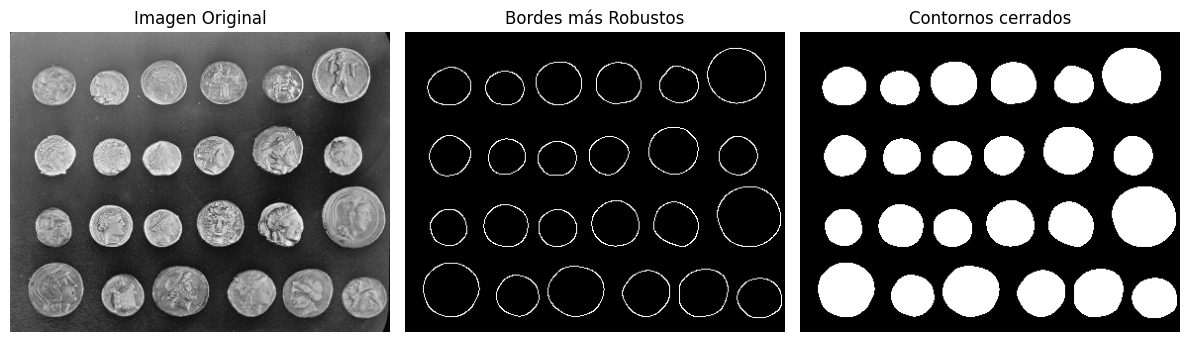

In [3]:
# Detectamos los bordes de forma más robusta
edges2 = canny(coins, sigma=4) 

# Rellenamos los contornos cerrados 
fill_coins2 = ndi.binary_fill_holes(edges2)

# Mostrar los resultados
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].imshow(coins, cmap="gray"); axes[0].set_axis_off(); axes[0].set_title('Imagen Original')
axes[1].imshow(edges2, cmap="gray"); axes[1].set_axis_off(); axes[1].set_title('Bordes más Robustos')
axes[2].imshow(fill_coins2, cmap="gray"); axes[2].set_axis_off(); axes[2].set_title('Contornos cerrados')
plt.tight_layout()
plt.show()

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='regiones09'></a>

## Segmentación basada en Regiones

La segmentación basada en regiones es un enfoque que se centra en dividir una imagen en áreas conectadas que representan objetos o partes significativas de una escena. A continuación, exploraremos algunas de las técnicas más relevantes.

### Crecimiento de Regiones

El [crecimiento de regiones](https://en.wikipedia.org/wiki/Image_segmentation#Region-growing_methods) es una técnica de segmentación que comienza seleccionando uno o más píxeles semillas y luego expande la región agregando píxeles vecinos que son similares a los píxeles de la región. Este enfoque es iterativo y se basa en un criterio de similitud que puede incluir la intensidad del píxel, el color, la textura u otros atributos. La expansión continúa hasta que no hay más píxeles vecinos que cumplan con el criterio de similitud. El siguiente código ejemplifica este tipo de técnica.

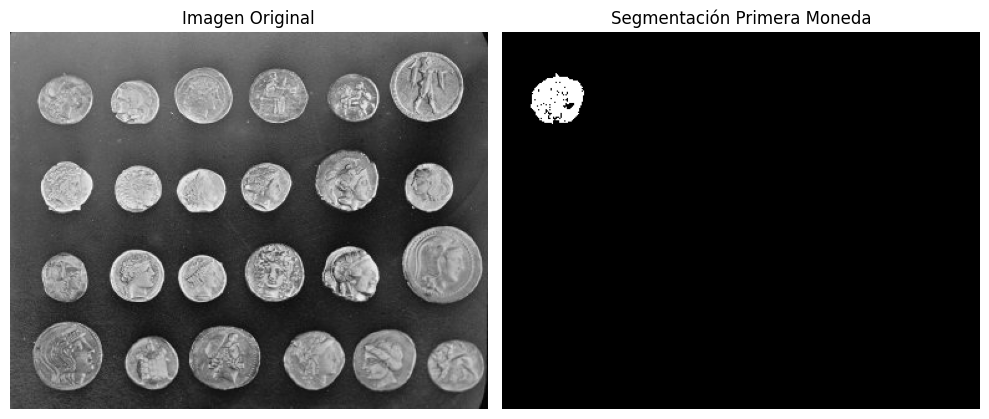

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Cargar la imagen de monedas de skimage
coins = data.coins()

# Normalizar la imagen
coins = coins / 255.0

# Inicializar la imagen de segmentación con ceros
segmentation = np.zeros_like(coins)

# Definir la semilla sobre la primera moneda
seed = (50,50)
segmentation[seed] = 1

# Definir el umbral de intensidad (teniendo en cuenta la normalización entre 0 y 1)
threshold = 0.04

# Función para obtener los vecinos de un píxel (8-conectividad)
def get_neighbors(x, y, shape):
    neighbors = []
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue
            nx, ny = x + dx, y + dy
            if 0 <= nx < shape[0] and 0 <= ny < shape[1]:
                neighbors.append((nx, ny))
    return neighbors

# Lista de píxeles a procesar
to_process = [seed]

# Algoritmo de crecimiento de regiones
while to_process:
    x, y = to_process.pop()
    for nx, ny in get_neighbors(x, y, coins.shape):
        if segmentation[nx, ny] == 0 and abs(coins[nx, ny] - coins[x, y]) < threshold:
            segmentation[nx, ny] = 1
            to_process.append((nx, ny))

# Mostrar los resultados
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(coins, cmap="gray"); axes[0].set_axis_off(); axes[0].set_title('Imagen Original')
axes[1].imshow(segmentation, cmap="gray"); axes[1].set_axis_off(); axes[1].set_title('Segmentación Primera Moneda')
plt.tight_layout()
plt.show()

Como se puede observar, la segmentación por crecimiento de regiones permite identificar áreas homogéneas, como la moneda sobre la que se sitúa la semilla inicial. Sin embargo, es crucial ajustar adecuadamente el umbral de intensidad para garantizar una segmentación precisa. Un umbral mal ajustado puede generar fácilmente segmentaciones incorrectas, por lo que resulta esencial experimentar con diferentes valores y preprocesar la imagen para minimizar el ruido y mejorar la calidad de la segmentación.

### Algoritmo de Watershed

El algoritmo de [Watershed](https://en.wikipedia.org/wiki/Watershed_(image_processing)) es una técnica de segmentación que interpreta la imagen como una superficie tridimensional, donde las intensidades de los píxeles se consideran alturas. Se comienza marcando los puntos más bajos (mínimos locales) y se simula el llenado de agua desde estos puntos. A medida que el agua sube, se llenan las cuencas hasta que se encuentran, formando las líneas de cresta que separan las diferentes regiones. Esta técnica es muy efectiva para segmentar objetos en imágenes donde los bordes no son fácilmente detectables por métodos de detección de bordes convencionales. El siguiente código de ejemplo ilustra cómo se aplica el algoritmo de Watershed para segmentar una imagen en regiones significativas.

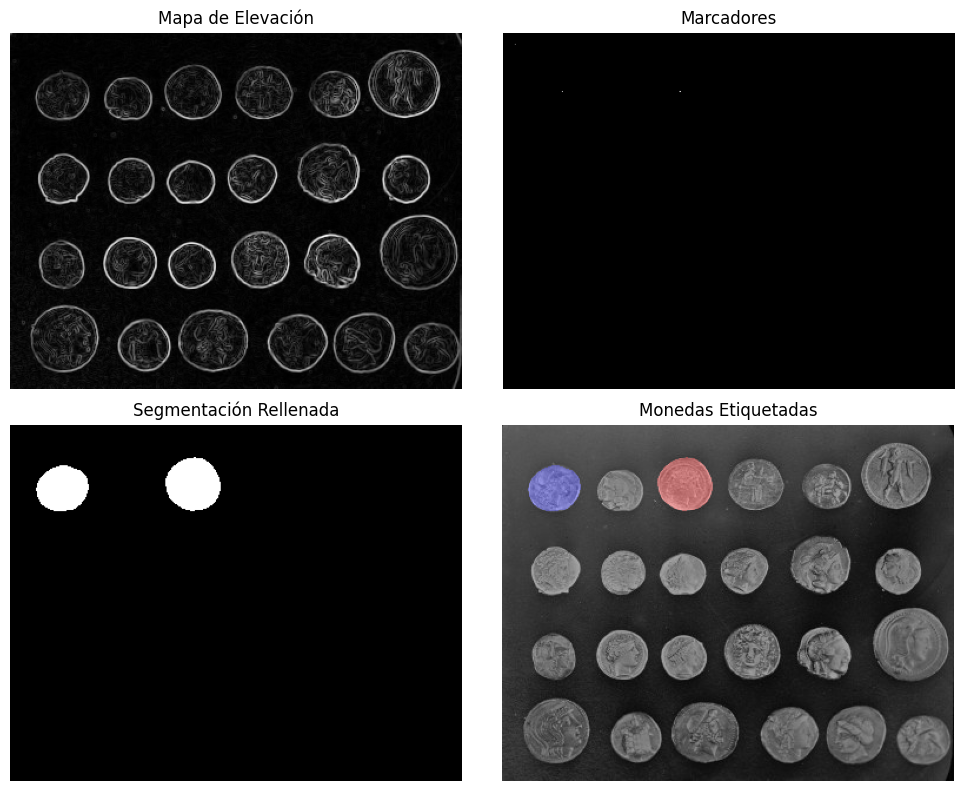

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.filters import sobel
from skimage.segmentation import watershed
from scipy import ndimage as ndi
from skimage.color import label2rgb

# Cargar la imagen de monedas de skimage
coins = data.coins()

# Normalizar la imagen (opcional)
coins = coins / 255.0

# Calcular el mapa de elevación utilizando el filtro de Sobel
elevation_map = sobel(coins)

# Crear los marcadores
markers = np.zeros(coins.shape, dtype=np.int32)
markers[(10,10)]= 1 # marcador en el fondo
markers[(50,50)]= 2 # marcador en la primera moneda
markers[(50,150)]= 3 # marcador en la tercera moneda

# Aplicar el algoritmo de Watershed
segmentation = watershed(elevation_map, markers)

# Rellenar los agujeros en la segmentación
segmentation_filled = ndi.binary_fill_holes(segmentation - 1) # restamos 1 para tener fondo=0, monedas=1,2

# Etiquetar las regiones segmentadas
labeled_coins, _ = ndi.label(segmentation_filled)

# Superponer las etiquetas en la imagen original
image_label_overlay = label2rgb(labeled_coins, image=coins, bg_label=0)

# Mostrar los resultados en un subplot de 2x2
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(elevation_map, cmap="gray")
axes[0, 0].set_axis_off()
axes[0, 0].set_title('Mapa de Elevación')
axes[0, 1].imshow(markers, cmap="gray")
axes[0, 1].set_axis_off()
axes[0, 1].set_title('Marcadores')
axes[1, 0].imshow(segmentation_filled, cmap="gray")
axes[1, 0].set_axis_off()
axes[1, 0].set_title('Segmentación Rellenada')
axes[1, 1].imshow(image_label_overlay)
axes[1, 1].set_axis_off()
axes[1, 1].set_title('Monedas Etiquetadas')
plt.tight_layout()
plt.show()

Los resultados muestran que el algoritmo de Watershed es capaz de segmentar las monedas en la imagen de manera efectiva. El mapa de elevación calculado con el filtro de Sobel ayuda a delinear los contornos de las monedas, mientras que los marcadores iniciales guían la segmentación al marcar el fondo y las dos monedas seleccionadas. En este caso, el resultado obtenido es bastante bueno, pero, en general, es necesario ajustar cuidadosamente los marcadores y realizar un preprocesamiento adecuado para reducir el ruido y mejorar la precisión de la segmentación. La imagen final muestra las dos monedas segmentadas, superpuestas sobre la imagen original.

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='clustering09'></a>

## Segmentación basada en Clustering

La segmentación basada en clustering es una técnica que agrupa píxeles de una imagen en distintas regiones o clústeres según sus características similares, como la intensidad del color o la textura. Este método no requiere información previa sobre los objetos en la imagen, sino que clasifica los píxeles basándose en sus similitudes. Técnicas como K-means, Mean Shift y clustering jerárquico son comúnmente utilizadas para este propósito. La segmentación por clustering es especialmente útil en aplicaciones donde los objetos no tienen contornos bien definidos, permitiendo una segmentación más flexible y adaptativa de las diferentes regiones de la imagen.

### Algoritmo SLIC (superpíxeles)

Una de las técnicas más avanzadas y populares de segmentación por clustering es SLIC (Simple Linear Iterative Clustering). SLIC agrupa píxeles en superpíxeles, que son regiones compactas y similares dentro de la imagen. Este algoritmo es especialmente eficiente para segmentar imágenes en regiones significativas, lo que facilita el procesamiento y análisis posterior. A continuación, se muestra un ejemplo de cómo aplicar el algoritmo SLIC para segmentar una imagen.

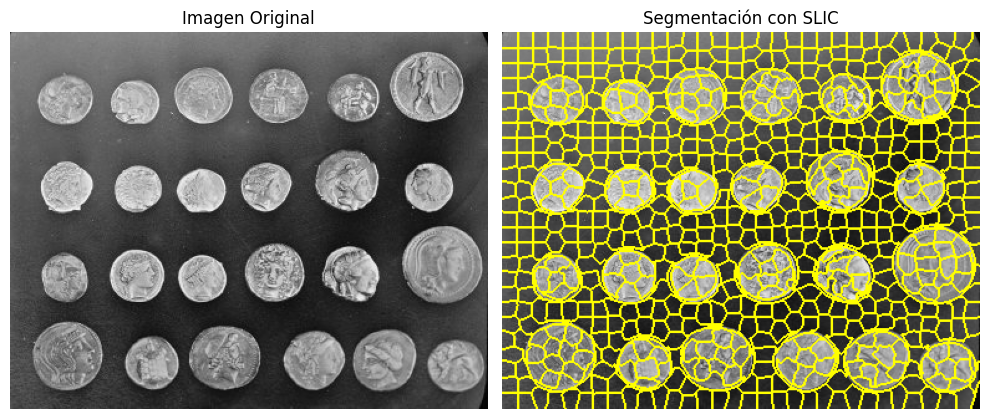

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.segmentation import slic, mark_boundaries

# Cargar la imagen de monedas de skimage
coins = data.coins()

# Normalizar la imagen (opcional)
coins = coins / 255.0

# Convertir la imagen a RGB (SLIC requiere imágenes en color)
coins_rgb = color.gray2rgb(coins)

# Aplicar SLIC para segmentar la imagen en superpíxeles
segments = slic(coins_rgb, n_segments=800, compactness=10, sigma=2, start_label=1)

# Mostrar los resultados
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(coins, cmap="gray"); axes[0].set_axis_off(); axes[0].set_title('Imagen Original')
segmented_image = mark_boundaries(coins_rgb, segments) # marcar los límites de los superpíxeles en la imagen original
axes[1].imshow(segmented_image); axes[1].set_axis_off(); axes[1].set_title('Segmentación con SLIC')
plt.tight_layout()
plt.show()

En este código, el algoritmo SLIC se utiliza para segmentar la imagen en superpíxeles, proporcionando una representación más estructurada y manejable de la imagen original. Esto facilita la identificación y análisis de las diferentes regiones de la imagen, permitiendo una segmentación más precisa y eficiente. Los parámetros más importantes de la función `slic` incluyen `n_segments`, que determina el número de superpíxeles, `compactness`, que controla la adherencia a los bordes, y `sigma`, que suaviza la imagen para reducir el ruido, permitiendo ajustar el algoritmo a las características específicas de la imagen. Fíjate que la función `slic` devuelve como resultado un mapa de etiquetas, donde cada píxel contiene un valor entero que indica el superpíxel al que pertenece.

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='movimiento09'></a>

## Segmentación basada en Movimiento

La segmentación basada en movimiento es una técnica que identifica y separa objetos en una secuencia de imágenes o videos basándose en el cambio de posición de los píxeles a lo largo del tiempo. Utilizando métodos como la sustracción de fondo, es posible distinguir entre píxeles en movimiento y estáticos. Este tipo de segmentación es especialmente útil en aplicaciones de vigilancia, seguimiento de objetos y análisis de tráfico, donde es crucial detectar objetos en movimiento de manera precisa y dinámica.

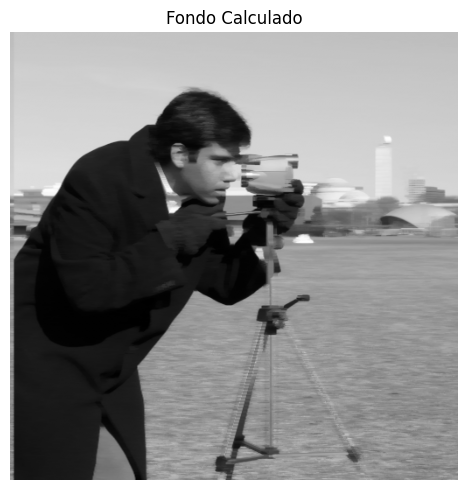

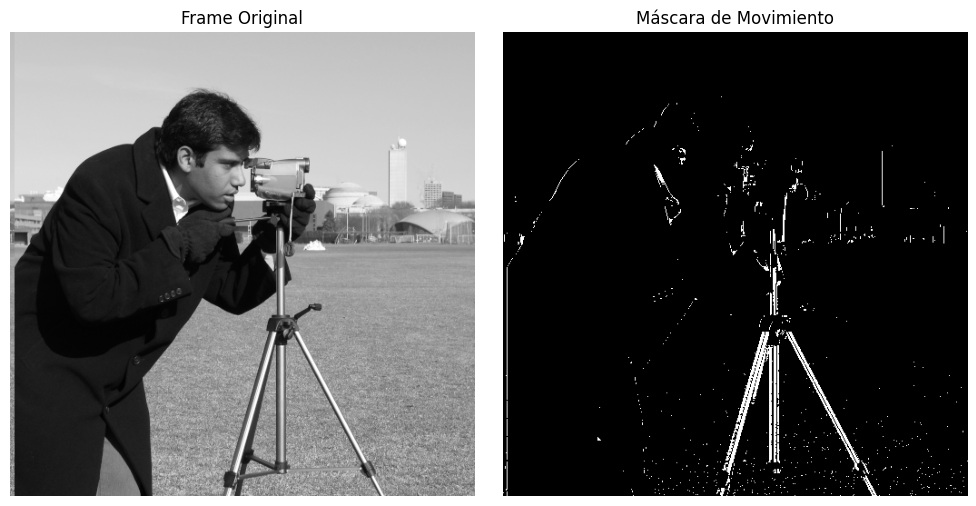

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.filters import threshold_otsu
from skimage.feature import canny

# Cargar una secuencia de imágenes
# Usaremos la secuencia de imágenes del vídeo de la biblioteca de skimage
video = data.camera()
video = np.stack([video for _ in range(10)], axis=0)  # Simular un vídeo con múltiples frames idénticos

# Añadir movimiento en la secuencia
for i in range(10):
    video[i] = np.roll(video[i], shift=i, axis=1)

# Estimar el fondo como la mediana de todos los frames
background = np.median(video, axis=0)

# Mostrar el fondo
plt.figure(figsize=(10, 5))
plt.imshow(background, cmap='gray')
plt.title('Fondo Calculado')
plt.axis('off')
plt.tight_layout()
plt.show()

# Detectar movimiento restando el fondo de cada frame
motion_masks = np.abs(video - background) > threshold_otsu(np.abs(video - background))

# Mostrar un frame con su máscara de movimiento
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(video[5], cmap='gray')
axes[0].set_title('Frame Original')
axes[0].axis('off')
axes[1].imshow(motion_masks[5], cmap='gray')
axes[1].set_title('Máscara de Movimiento')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Este código muestra un ejemplo de cómo detectar movimiento en una secuencia de imágenes utilizando la técnica de sustracción de fondo. Primero, se calcula el fondo como la mediana de todos los frames del video. Luego, se detecta el movimiento restando el fondo de cada frame y aplicando un umbral para identificar las áreas en movimiento. En este ejemplo, el fondo calculado se muestra junto con un frame original y su correspondiente máscara de movimiento, lo que permite visualizar las diferencias entre el fondo estático y las regiones dinámicas de la escena. Esta técnica es eficaz para detectar cambios en secuencias de video, especialmente en escenarios con fondos relativamente constantes.

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='ejercicios09'></a>

## Ejercicios de práctica

### *Ejercicio 1. Segmentación de Aves*

Desarrolla un programa en Python para segmentar la imagen `images/birds.jpg` utilizando técnicas de segmentación por bordes. Comienza cargando la imagen y analizándola. Seguidamente, aplica la técnica de detección de bordes que consideres más apropiada, junto con los preprocesamientos necesarios para mejorar la detección de contornos de las aves que aparecen en la imagen. Ajusta cuidadosamente todos los elementos para asegurar que se realiza una segmentación clara y precisa. Finalmente, muestra la imagen original, el mapa de bordes detectado y la imagen final segmentada.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="images/ej1_birds.jpg" style="width:80%; height:auto; margin-right: 50px;">
</div>
<br><br>

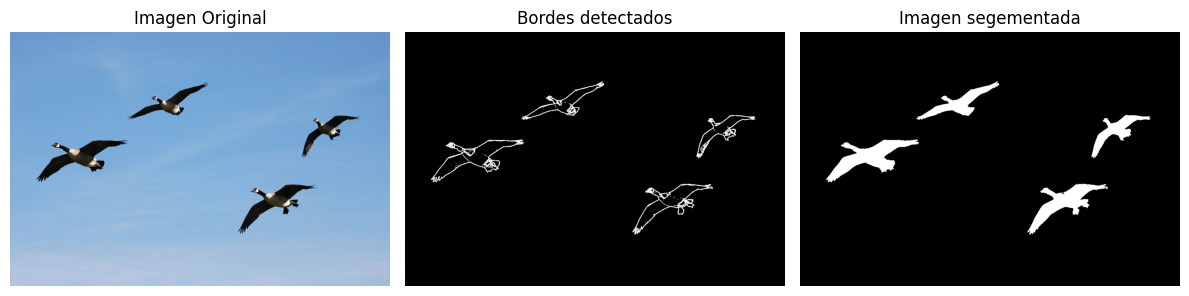

In [8]:
# Segmentación, aplicar Canny
from skimage.io import imread
from scipy.ndimage import gaussian_laplace


original = imread('images/birds.jpg')
birds = imread('images/birds.jpg', as_gray=True)

elevation_map = sobel(birds)

threshold_value = 0.05
# Crear una imagen binaria usando el umbral calculado
binary_image = elevation_map > threshold_value

fill_birds = ndi.binary_fill_holes(binary_image)
# Mostrar los resultados
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].imshow(original); axes[0].set_axis_off(); axes[0].set_title('Imagen Original')
axes[1].imshow(binary_image, cmap="gray"); axes[1].set_axis_off(); axes[1].set_title('Bordes detectados')
axes[2].imshow(fill_birds, cmap="gray"); axes[2].set_axis_off(); axes[2].set_title('Imagen segementada')
plt.tight_layout()
plt.show()

### *Ejercicio 2. Segmentación de Escena*

Implementa un programa en Python para segmentar una escena de una playa utilizando técnicas de segmentación por regiones. Comienza cargando la imagen `images/beach.jpg` y conviértela a escala de grises para simplificar su procesamiento. A continuación, utiliza técnicas de segmentación basada en regiones para segmentar solamente las áreas superior e inferior que se corresponden con el cielo y la arena de la playa respectivamente. Asegúrate de utilizar las semillas adecuadas para lograr detectar las zonas deseadas y de aplicar los pre/post-procesamientos necesarios para lograr un óptimo resultado. Muestra la imagen original y el mapa de segmentación obtenido para comprobar el correcto funcionamiento de tu programa.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="images/ej2_beach.jpg" style="width:70%; height:auto; margin-right: 50px;">
</div>
<br><br>

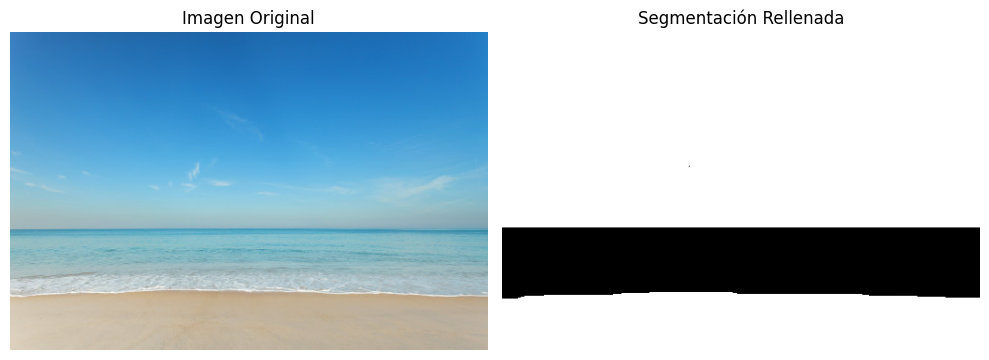

In [9]:
# Conveniente aplicar un poco de suavizado
from skimage import filters
# Segmentación por regiones 
beach = imread('images/beach.jpg', as_gray=True)
original = imread('images/beach.jpg')

# Calcular el mapa de elevación utilizando el filtro de Sobel

suavizada = filters.gaussian(beach, sigma=1.5)

segmentation = np.zeros_like(suavizada)

# Definir la semilla sobre la primera moneda
seed1 = (50,256)
seed2 = (300,256)
segmentation[seed1] = 1
segmentation[seed2] = 1

# Definir el umbral de intensidad (teniendo en cuenta la normalización entre 0 y 1)
threshold = 0.005

# Lista de píxeles a procesar
to_process = [seed1, seed2]

# Algoritmo de crecimiento de regiones
while to_process:
    x, y = to_process.pop()
    for nx, ny in get_neighbors(x, y, suavizada.shape):
        if segmentation[nx, ny] == 0 and abs(suavizada[nx, ny] - suavizada[x, y]) < threshold:
            segmentation[nx, ny] = 1
            to_process.append((nx, ny))

segmentation = ndi.median_filter(segmentation, size=8)

# Mostrar los resultados
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original); axes[0].set_axis_off(); axes[0].set_title('Imagen Original')
axes[1].set_title('Segmentación Rellenada')
axes[1].imshow(segmentation, cmap='gray')
axes[1].set_axis_off()
plt.tight_layout()
plt.show()


### *Ejercicio 3. Efecto de Pixelación*

Desarrolla un programa en Python para segmentar una escena de un parking utilizando la técnica de segmentación basada en clustering SLIC y aplicar un efecto artístico de pixelación. Comienza cargando la imagen `images/carpark.jpg`. A continuación, aplica el algoritmo SLIC para segmentar la imagen en superpíxeles. Calcula la media de color dentro de cada superpíxel y asigna este valor a todos los píxeles del superpíxel para obtener el efecto de pixelación. Asegúrate de ajustar los parámetros de detección para que el resultado obtenido se asemeje al esperado. Muestra la imagen original y la imagen final pixelada para verificar la correcta implementación de tu programa.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="images/ej3_carpark.jpg" style="width:70%; height:auto; margin-right: 50px;">
</div>
<br><br>

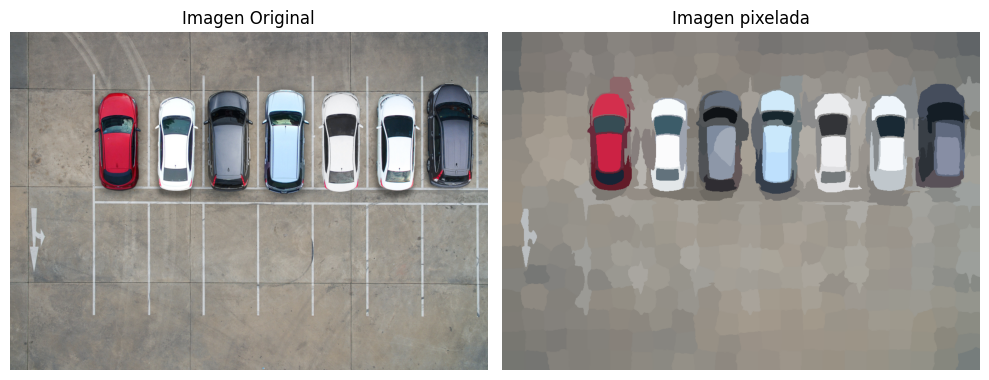

In [10]:
# Superpixeles SLIC
# Dejamos la imagenes en RGB ya que SLIC lo requiere
parking = imread('images/carpark.jpg')

segments = slic(parking, n_segments=350, compactness=12, sigma=2.1, start_label=1)

pixelada = np.zeros_like(parking)

# Para cada etiqueta de superpíxel
for label in np.unique(segments):
    mask = segments == label  # Máscara que indica aquellos píxeles que pertenecen a una misma etiqueta
    mean_color = parking[mask].mean(axis=0)  # media RGB del superpíxel
    pixelada[mask] = mean_color  
	  
# Mostrar los resultados
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(parking); axes[0].set_axis_off(); axes[0].set_title('Imagen Original')
axes[1].imshow(pixelada); axes[1].set_axis_off(); axes[1].set_title('Imagen pixelada')
plt.tight_layout()
plt.show()

### *Ejercicio 4. Acceso Zona Restringida*

Desarrolla un programa en Python para detectar accesos a una zona restringida de una instalación a partir de secuencias de video. Comienza cargando la máscara que define la zona restringida `images/restricted.png`, así como la secuencia de video `images/video.mp4` con la función `video_to_frames` proporcionada. A continuación, convierte cada frame a escala de grises y analiza el movimiento entre frames consecutivos. Utiliza la técnica de umbralización de Otsu para detectar áreas de movimiento significativo y filtra el resultado con un filtro de mediana para reducir el ruido. Finalmente, verifica si alguno de estos movimientos detectados se superpone con la zona restringida marcada por la máscara. Asegúrate de ajustar cuidadosamente los umbrales y parámetros de detección para obtener un resultado preciso. Muestra visualmente el primer frame, la máscara de la zona restringida, la diferencia absoluta entre frames, la máscara de movimiento, y el frame en el cual se detecta la intrusión.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="images/ej4_restricted.jpg" style="width:70%; height:auto; margin-right: 50px;">
</div>
<br><br>

In [11]:
import numpy as np
import cv2

def video_to_frames(video_path):

    '''Función para extraer los frames de un archivo de video en formato RGB utilizando OpenCV'''
    
    # Objeto de captura de video
    cap = cv2.VideoCapture(video_path)
    
    # Verificar si el video se abrió correctamente
    if not cap.isOpened():
        print("Error al abrir el video")
        return np.array([])

    # Extraer los frames del video   
    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        # Convertir el frame de BGR a RGB
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Liberar el objeto de captura y devolver los frames como un array de NumPy
    cap.release()
    return np.array(frames)

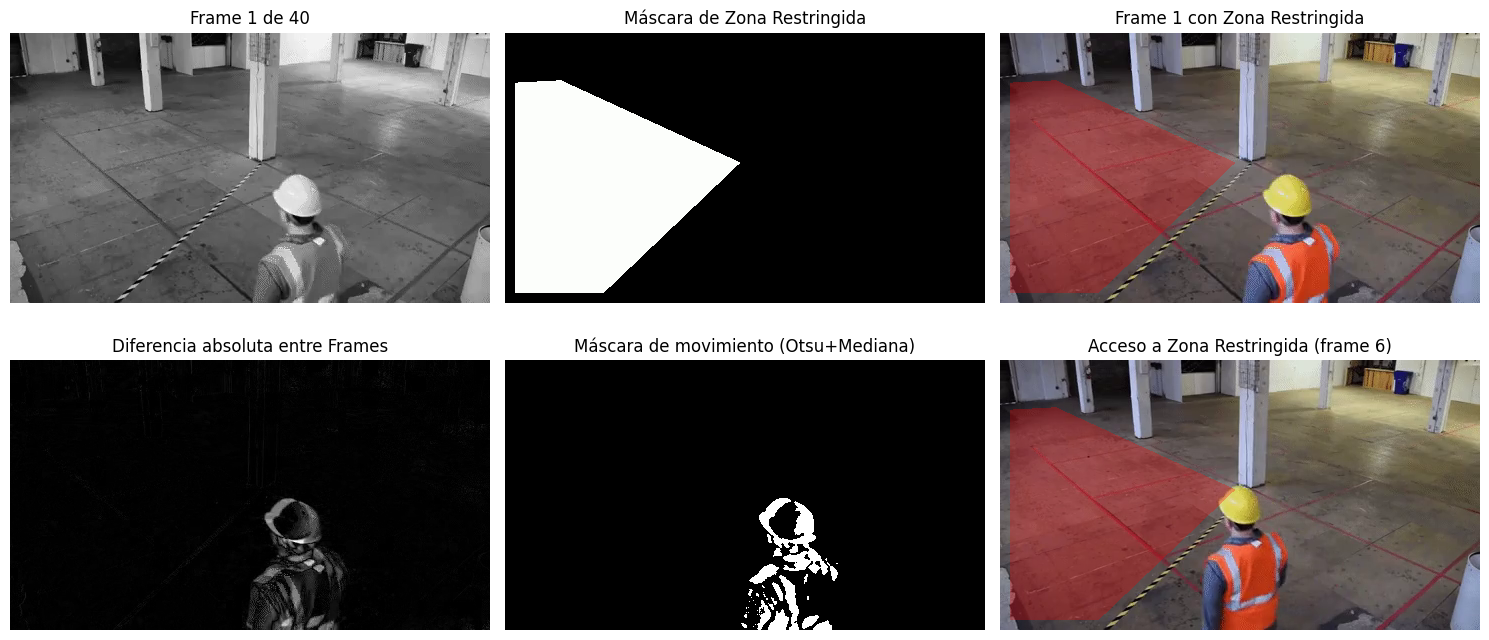

In [12]:
from skimage.color import rgb2gray
from scipy.ndimage import median_filter
# 1.Cargamos video
video = video_to_frames('images/video.mp4')
video_gris = np.array([rgb2gray(frame) for frame in video])

# 2.Cargamos la máscara 
mask = imread('images/restricted.png')
mask_rgb = mask[..., :3]

# Convertimos a escala de grises para separar blanco de negro
mask_gray = rgb2gray(mask_rgb)

# Creamos máscara booleana donde es blanco
mask_bool = mask_gray > 0.5

# 3.Frame 1 con zona restringida
# Hacemos el overlay
zona_restringida = video[0].copy()

alpha = 0.3        

# color rojo puro
red = np.array([255, 0, 0], dtype=np.uint8)

# aplicar blending sólo donde la máscara es True
zona_restringida[mask_bool] = (1 - alpha) * zona_restringida[mask_bool] + alpha * red

# 4.Diferencia absoluta entre frames
frame1 = video_gris[0].astype(float)
frame2 = video_gris[1].astype(float)

# Diferencia absoluta
diff = np.abs(frame1 - frame2)

# 5.Mascara de movimiento
# Aplicamos un filtro mediana para quitar el ruido de la diferencia entre los dos primeros frames
diff_med = median_filter(diff, size=3)

# Calculamos las máscaras de movimientol de Otsu
motion_mask = diff_med > threshold_otsu(diff_med)


# 6.Acceso a zona restringida
# Hacemos el overlay
acceso_zona = video[5].copy()

alpha = 0.3        

# color rojo puro
red = np.array([255, 0, 0], dtype=np.uint8)

# aplicar blending sólo donde la máscara es True
acceso_zona[mask_bool] = (1 - alpha) * acceso_zona[mask_bool] + alpha * red

# Mostrar un frame con su máscara de movimiento
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes[0][0].imshow(video_gris[0], cmap='gray')
axes[0][0].set_title('Frame 1 de 40')
axes[0][0].axis('off')
axes[0][1].imshow(mask, cmap='gray')
axes[0][1].set_title('Máscara de Zona Restringida')
axes[0][1].axis('off')
axes[0][2].imshow(zona_restringida)
axes[0][2].set_title('Frame 1 con Zona Restringida')
axes[0][2].axis('off')
axes[1][0].imshow(diff, cmap='gray')
axes[1][0].set_title('Diferencia absoluta entre Frames')
axes[1][0].axis('off')
axes[1][1].imshow(motion_mask, cmap='gray')
axes[1][1].set_title('Máscara de movimiento (Otsu+Mediana)')
axes[1][1].axis('off')
axes[1][2].imshow(acceso_zona)
axes[1][2].set_title('Acceso a Zona Restringida (frame 6)')
axes[1][2].axis('off')

plt.tight_layout()
plt.show()